In [27]:
import os 
import sys

import numpy as np
import matplotlib.pyplot as plt
import cv2 


root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects


In [28]:
# === config ===

SEQ_ID = 1
FRAME_NO = 345

In [29]:
sequence_dir = os.path.join(root_dir, f'data/seq_{SEQ_ID}/fls')

frames = sorted(
    os.listdir(sequence_dir),
    key=lambda x: int(os.path.splitext(x)[0])
)

img_pth = os.path.join(sequence_dir, frames[FRAME_NO])

frame_sim = cv2.imread(img_pth, 0)

# add noise
frame_sim_noise = addBandReflects(frame_sim.copy(), omega1 = 0.03, omega2 = 0.07, gain = 0.02)
# I = energyLoss(I, alpha = 0.02)
frame_sim_noise = addSpeckleNoise(frame_sim_noise, m_min = 30, m_max = 100, sigma = 0.25, beam_width=2.0)
frame_sim_noise = polar2cartesian(frame_sim_noise, r_min = 0.5, r_max = 30.0, theta_min = -65*np.pi/180, theta_max = 65*np.pi/180, out_shape = None)
frame_sim_noise = frame_sim_noise.astype(np.uint8)

In [32]:
real_data_dir = 'data/aracati/data_example'
REAL_FRAME_NO = 2500
real_frame_pth = os.path.join(root_dir, real_data_dir, f'{REAL_FRAME_NO}.png')
print(real_frame_pth)
frame_real = cv2.imread(real_frame_pth, 0)

print(frame_real.shape)

c:\Users\janis\Projekty\Magisterka\SonarOdometry\data/aracati/data_example\2500.png
(848, 1553)


Text(0.5, 1.0, 'real fls frame')

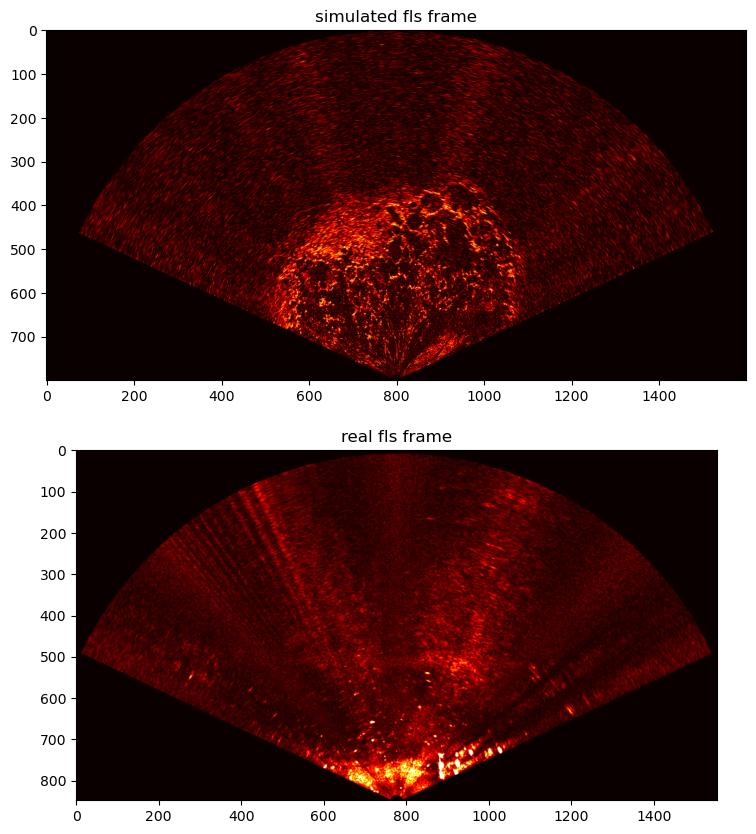

In [33]:
fig, ax = plt.subplots(2, 1, figsize = (20, 10))

ax[0].imshow(frame_sim_noise, cmap = 'hot')
ax[0].set_title('simulated fls frame')

ax[1].imshow(frame_real, cmap = 'hot')
ax[1].set_title('real fls frame')

